In [ ]:
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 14.3 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
import os

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
os.environ["OPENROUTER_API_KEY"]="api_key"

llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1"
)

In [ ]:
class TelecomState(TypedDict):

    complaint:str

    intent:str
    sentiment:str
    entities:str
    severity:str

    tower_status:str
    crm_history:str
    billing_status:str
    next_route:str
    assigned_team:str

    customer_response:str
    technician_note:str
    eta:str

    final_summary:str

In [ ]:
def extract_intent(state):
    prompt = f"""
You are an AI Telecom Complaint Classification Agent.

Your responsibility is to analyze customer complaints
submitted to a telecom support system.

Carefully analyze the complaint and identify:

1. Primary issue category
2. Secondary issue category if present
3. Whether the issue is:
   - Network issue
   - Billing issue
   - SIM issue
   - Device issue
   - Coverage issue
   - Tower outage
   - Recharge issue
   - Connectivity issue

4. Detect whether the issue impacts:
   - Single customer
   - Multiple customers
   - Entire region

5. Detect urgency indicators.

Return response in structured format.

Complaint:
{state['complaint']}
"""
    response=llm.invoke(prompt)
    return {"intent":response.content}



In [ ]:
def analyze_sentiment(state):
    prompt = f"""
You are a Telecom Customer Emotion Analysis Agent.

Analyze the emotional tone of the customer complaint.

Your objectives:

1. Identify customer sentiment:
   - Calm
   - Frustrated
   - Angry
   - Highly distressed
   - Emergency-like panic

2. Detect escalation indicators.

3. Detect whether customer dissatisfaction
   may lead to churn risk.

4. Estimate emotional severity score
   from 1 to 10.

5. Explain why the score was assigned.

Complaint:
{state['complaint']}

Return:
- Sentiment
- Severity Score
- Explanation
"""
    response=llm.invoke(prompt)
    return {"sentiment":response.content}



In [ ]:
def extract_entities(state):
    prompt = f"""
You are a Telecom Entity Extraction Agent.

Extract all operationally useful entities
from the customer complaint.

Identify:

1. Region/location
2. Tower references
3. Device model if mentioned
4. SIM details
5. Network type:
   - 4G
   - 5G
   - VoLTE
   - Broadband

6. Time references:
   - Since morning
   - Since recharge
   - Since yesterday

7. Frequency indicators:
   - Continuous
   - Intermittent
   - Random

Complaint:
{state['complaint']}

Return structured entities.
"""
    response=llm.invoke(prompt)
    return {"entities":response.content}



In [ ]:
def severity_analysis(state):
    prompt = f"""
You are a Telecom Severity Assessment Agent.

Your role is to determine operational severity
for telecom incidents.

Analyze the following inputs:

Complaint:
{state['complaint']}

Intent Analysis:
{state['intent']}

Sentiment Analysis:
{state['sentiment']}

Entity Information:
{state['entities']}

Determine:

1. Incident severity:
   - Low
   - Medium
   - High
   - Critical

2. Business impact:
   - Single customer impact
   - Regional outage
   - Revenue risk
   - SLA violation risk

3. Customer impact scale.

4. Whether immediate escalation is needed.

5. Priority score from 1 to 100.

Provide detailed justification.
"""
    response=llm.invoke(prompt)
    return {"severity":response.content}

In [ ]:
def tower_check(state: TelecomState):

    prompt = f"""
    You are a Telecom Network Investigation Agent.

    Analyze likely network problems.

    Complaint:
    {state['complaint']}

    Severity:
    {state['severity']}

    Predict:
    - Tower congestion
    - Fiber cut
    - Signal degradation
    - Maintenance issue
    """

    response = llm.invoke(prompt)

    return {
        "tower_status": response.content
    }



In [ ]:
def crm_check(state: TelecomState):

    prompt = f"""
    You are a CRM Investigation Agent.

    Analyze complaint recurrence.

    Complaint:
    {state['complaint']}

    Determine:
    - Repeated issue possibility
    - Customer complaint frequency
    - Escalation history
    """

    response = llm.invoke(prompt)

    return {
        "crm_history": response.content
    }


In [ ]:
def billing_check(state: TelecomState):

    prompt = f"""
    You are a Telecom Billing Investigation Agent.

    Analyze whether complaint suggests:
    - Wrong billing
    - Recharge issue
    - Duplicate charges
    - Refund requirement

    Complaint:
    {state['complaint']}
    """

    response = llm.invoke(prompt)

    return {
        "billing_status": response.content
    }

In [ ]:
def route_issue(state):

    intent = state["intent"].lower()
    severity = state["severity"].lower()

    if "billing" in intent:

        return {
            "next_route":"billing"
        }

    elif "critical" in severity:

        return {
            "next_route":"escalation"
        }

    elif "device" in intent:

        return {
            "next_route":"device"
        }

    else:

        return {
            "next_route":"network"
        }

In [ ]:
def billing_agent(state):
    return {"assigned_team":"Billing Team"}

def network_agent(state):
    return {"assigned_team":"Network Ops"}

def escalation_agent(state):
    return {"assigned_team":"Emergency Escalation"}

def device_agent(state):
    return {"assigned_team":"Device Support"}

In [ ]:
def customer_response(state: TelecomState):

    prompt = f"""
    You are a Telecom Customer Communication Agent.

    Generate professional customer response.

    Complaint:
    {state['complaint']}

    Assigned Team:
    {state['assigned_team']}

    Severity:
    {state['severity']}
    """

    response = llm.invoke(prompt)

    return {
        "customer_response": response.content
    }

def technician_note(state: TelecomState):

    prompt = f"""
    You are a Telecom Internal Resolution Agent.

    Generate technician notes.

    Complaint:
    {state['complaint']}

    Tower Findings:
    {state['tower_status']}

    Billing Findings:
    {state['billing_status']}

    CRM History:
    {state['crm_history']}
    """

    response = llm.invoke(prompt)

    return {
        "technician_note": response.content
    }

def eta_prediction(state: TelecomState):

    prompt = f"""
    Predict estimated issue resolution time.

    Complaint:
    {state['complaint']}

    Severity:
    {state['severity']}

    Assigned Team:
    {state['assigned_team']}
    """

    response = llm.invoke(prompt)

    return {
        "eta": response.content
    }

def final_summary(state):

    summary=f"""
    Complaint: {state['complaint']}
    Team: {state['assigned_team']}
    ETA: {state['eta']}
    """

    return {"final_summary":summary}

In [ ]:
def route_selector(state):

    return state["next_route"]

In [ ]:
graph=StateGraph(TelecomState)

graph.add_node("intent",extract_intent)
graph.add_node("sentiment",analyze_sentiment)
graph.add_node("entities",extract_entities)
graph.add_node("severity",severity_analysis)

graph.add_node("tower",tower_check)
graph.add_node("crm",crm_check)
graph.add_node("billingcheck",billing_check)

graph.add_node("router", route_issue)

graph.add_edge("tower", "router")
graph.add_edge("crm", "router")
graph.add_edge("billingcheck", "router")

graph.add_node("billing",billing_agent)
graph.add_node("network",network_agent)
graph.add_node("escalation",escalation_agent)
graph.add_node("device",device_agent)

graph.add_node("custresponse",customer_response)
graph.add_node("tech",technician_note)
graph.add_node("eta",eta_prediction)

graph.add_node("summary",final_summary)

graph.add_edge(START,"intent")
graph.add_edge(START,"sentiment")
graph.add_edge(START,"entities")

graph.add_edge("intent","severity")
graph.add_edge("sentiment","severity")
graph.add_edge("entities","severity")

graph.add_edge("severity","tower")
graph.add_edge("severity","crm")
graph.add_edge("severity","billingcheck")

graph.add_conditional_edges(
    "router",
    route_selector,
    {
        "billing":"billing",
        "network":"network",
        "escalation":"escalation",
        "device":"device"
    }
)

graph.add_edge("billing","custresponse")
graph.add_edge("network","custresponse")
graph.add_edge("escalation","custresponse")
graph.add_edge("device","custresponse")

graph.add_edge("billing","tech")
graph.add_edge("network","tech")
graph.add_edge("escalation","tech")
graph.add_edge("device","tech")

graph.add_edge("billing","eta")
graph.add_edge("network","eta")
graph.add_edge("escalation","eta")
graph.add_edge("device","eta")

graph.add_edge("custresponse","summary")
graph.add_edge("tech","summary")
graph.add_edge("eta","summary")

graph.add_edge("summary",END)

workflow=graph.compile()

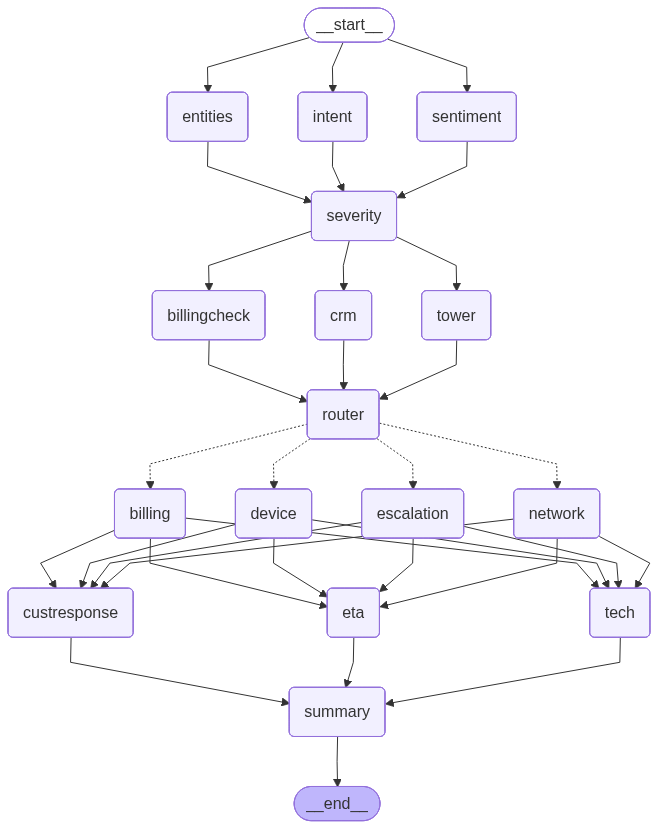

In [ ]:
workflow

In [ ]:
initial_state = {
    "complaint": """
    Entire area has no signal since morning.
    Multiple users are affected.
    Internet and calls are not working.
    Customers are very frustrated.
    """
}

output = workflow.invoke(initial_state)

In [ ]:
print("\n================ TECHNICIAN NOTE ================\n")
print(output["technician_note"])

print("\n================ ETA ================\n")
print(output["eta"])

print("\n================ FINAL SUMMARY ================\n")
print(output["final_summary"])


================ TECHNICIAN NOTE ================

### Technician Notes

**Date/Time of Entry**: [Insert Date/Time]  
**Technician Name**: [Insert Name]  
**Ticket Number**: [Insert Ticket Number]

#### Complaint Summary:
- **Reported Issue**: Total loss of signal in the entire area since this morning, affecting multiple users.
- **Services Impacted**: Internet and calls are both non-functional.
- **Customer Sentiment**: Frustration noted among affected users.

#### Initial Findings:
In response to the complaint, I have summarized the potential causes of the service outage and recommended actions based on my initial assessment of the situation.

### Potential Causes for the Outage:
1. **Fiber Cut**: Possible due to construction or severe weather. Investigate local reports or logs.
2. **Tower Congestion**: Unlikely to cause total signal loss but assess if simultaneous usage may appear as a complete outage.
3. **Maintenance Issue**: Check for any scheduled maintenance in the area that c